In [21]:
import kagglehub
import pandas as pd
import numpy as np
import os


try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Tuesday-WorkingHours.pcap_ISCX.csv' ))
    print('Tuesday data confirmed. :)')

except Exception as e:
    print(f'Something went wrong {e}')

data.head()



Tuesday data confirmed. :)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [22]:
data.columns = data.columns.str.strip()

print(data.shape)

print(data.dtypes)

(445909, 79)
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object


In [23]:
print(data.isnull().sum())
print('----')
print(data['Label'].value_counts())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64
----
Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64


In [24]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

X = data.drop('Label', axis=1)
y = data['Label']

scaler = StandardScaler()


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

#  Curious to see how Tuesday CSV was getting a pure 100%
#  High percentages tends to be from 'data leakage'
#  Conclusion: 'RandomForestClassifier' is too powerful for dataset
#  Accurately guesses all situations.
#  Dataset was too simple.

#  Debugging troubleshoot
#  Confirming X and Y values are in correct locations
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print("----")
#  Checking to see if theres data leakage
#  Ensuring scaler turned value to 'numpy.ndarray'
print(type(X_train))
print('----')
print(type(X_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     86310
           1       1.00      1.00      1.00      1614
           2       1.00      1.00      1.00      1205

    accuracy                           1.00     89129
   macro avg       1.00      1.00      1.00     89129
weighted avg       1.00      1.00      1.00     89129

(356516, 78)
(89129, 78)
(356516,)
(89129,)
----
<class 'numpy.ndarray'>
----
<class 'numpy.ndarray'>


Destination Port           0.254158
Init_Win_bytes_backward    0.038685
Fwd Packet Length Max      0.037912
Init_Win_bytes_forward     0.033965
Max Packet Length          0.031319
Packet Length Std          0.029526
Average Packet Size        0.029050
Bwd Header Length          0.027192
Fwd Packet Length Std      0.025779
Subflow Fwd Bytes          0.024396
dtype: float64


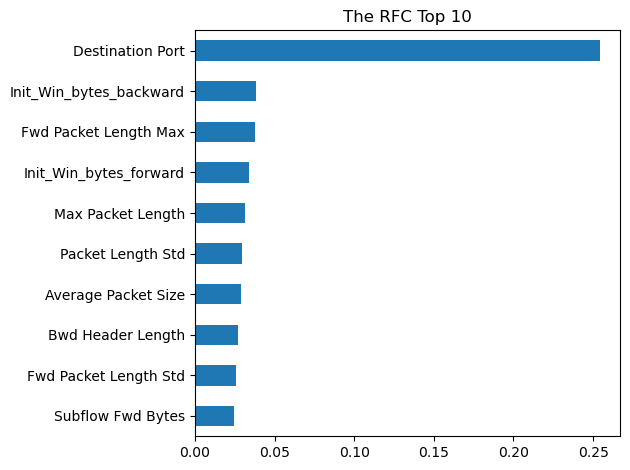

In [27]:
import matplotlib.pyplot as plt

rfc_importance = RandomForestClassifier(n_estimators = 100, random_state=1)
rfc_importance.fit(X,y)

importance = pd.Series(rfc_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).sort_values().plot(kind='barh')
plt.title('The RFC Top 10')
plt.tight_layout()
plt.show()